In [1]:
from __future__ import annotations
import os
import re
import bw2data
from bw2data import get_activity
from dataclasses import dataclass
from typing import Dict, Iterable, Literal, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# activate the bw project
bw2data.projects.set_current("ei311")

In [3]:
import sys
sys.path.append('../utils/') 
from dynamic_ghg_lcia import * 

## input file needed: 
- elec_path: dynamic LCI 
- ghg_dir:  all FaIR metrics, with uncertainty, we calc here, not via BW2 

In [4]:
elec_files = {
    ("SSP1-19", 2040): "elec_ssp119-2040.xlsx",
    ("SSP5-85", 2040): "elec_ssp585-2040.xlsx",
}
ghg_dir = "../../dpLCIA/FaIR_dpCFs/output/metrics"   # directory containing all CO2/CH4/N2O Excel files

# RF is the radiative forcing metric to use
metric = "rf"   # or "agwp", "gwp",  

In [5]:
results = compute_dynamic_lcia_for_scenarios(
    elec_files=elec_files,
    ghg_dir=ghg_dir,
    metric="rf",   # or "agwp" or "gwp" or "dcf"
)

print("FINISHED computing dpLCIA for multiple scenarios")
print(f"Scenarios computed: {list(results.keys())}")

FINISHED computing dpLCIA for multiple scenarios
Scenarios computed: [('SSP1-19', 2040), ('SSP5-85', 2040)]


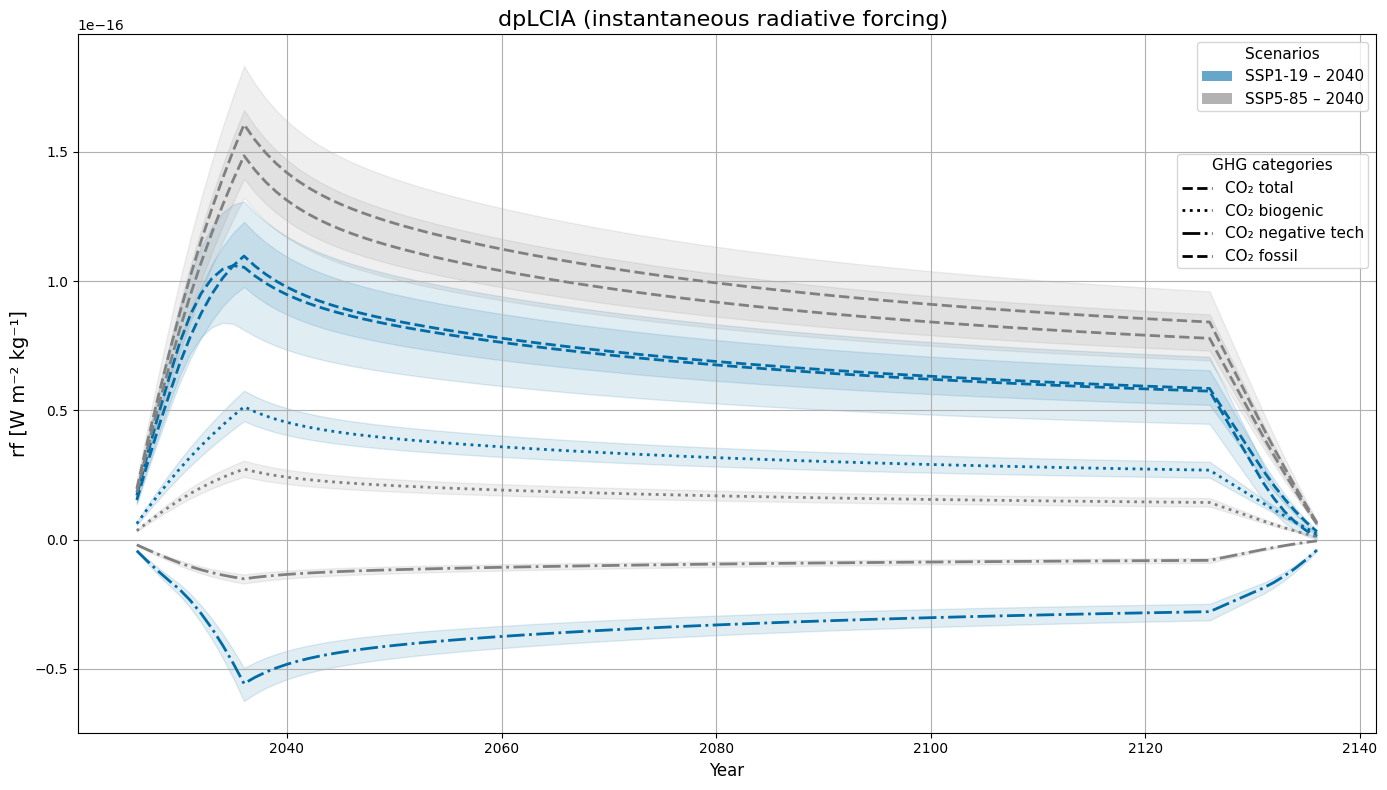

In [20]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results,
    metric="rf",
    gases_to_plot = [ 'co2_total', 'co2_biogenic', 'co2_other_negative', 'co2_fossil_positive']
)

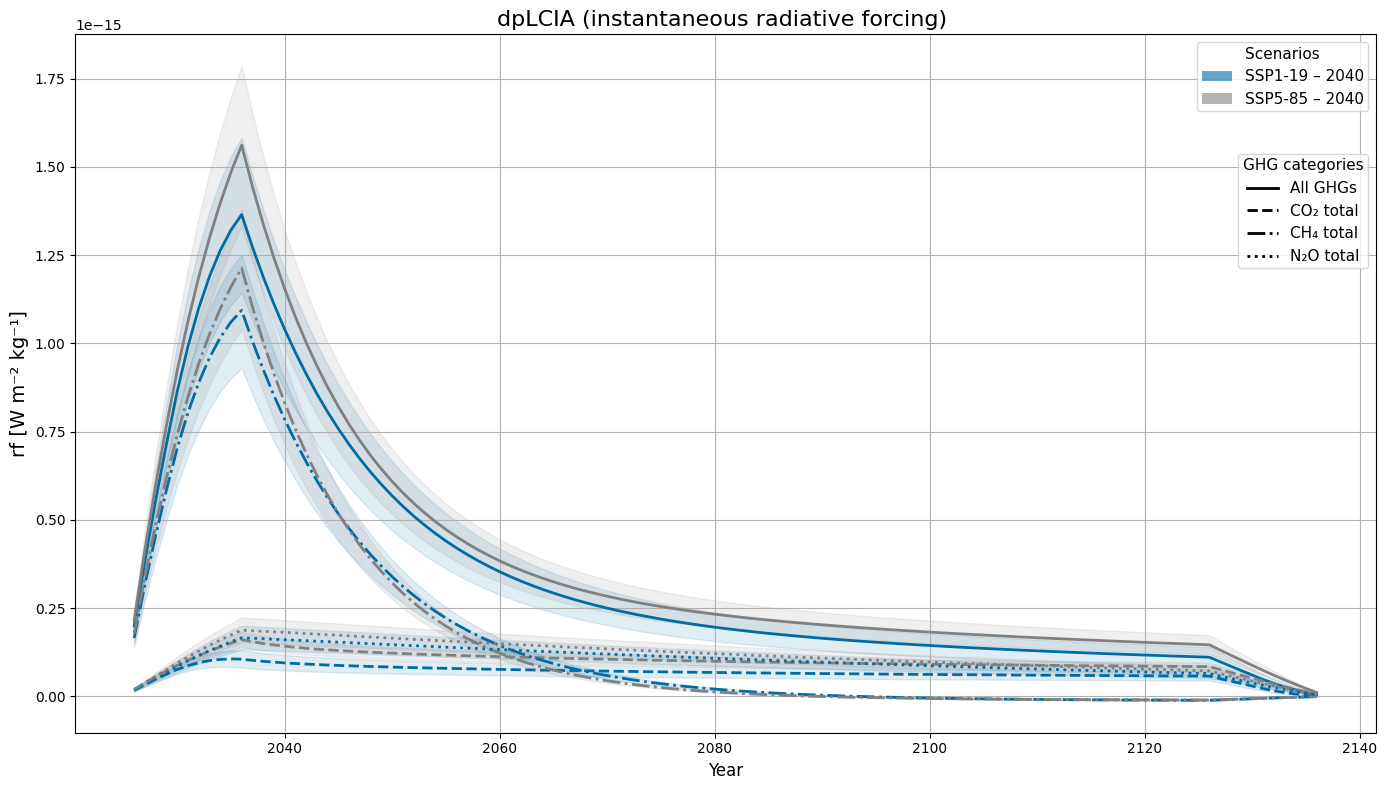

In [21]:
plot_multi_scenario_split_each_ghg_totalscore(
    results=results,
    metric="rf",
)


Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


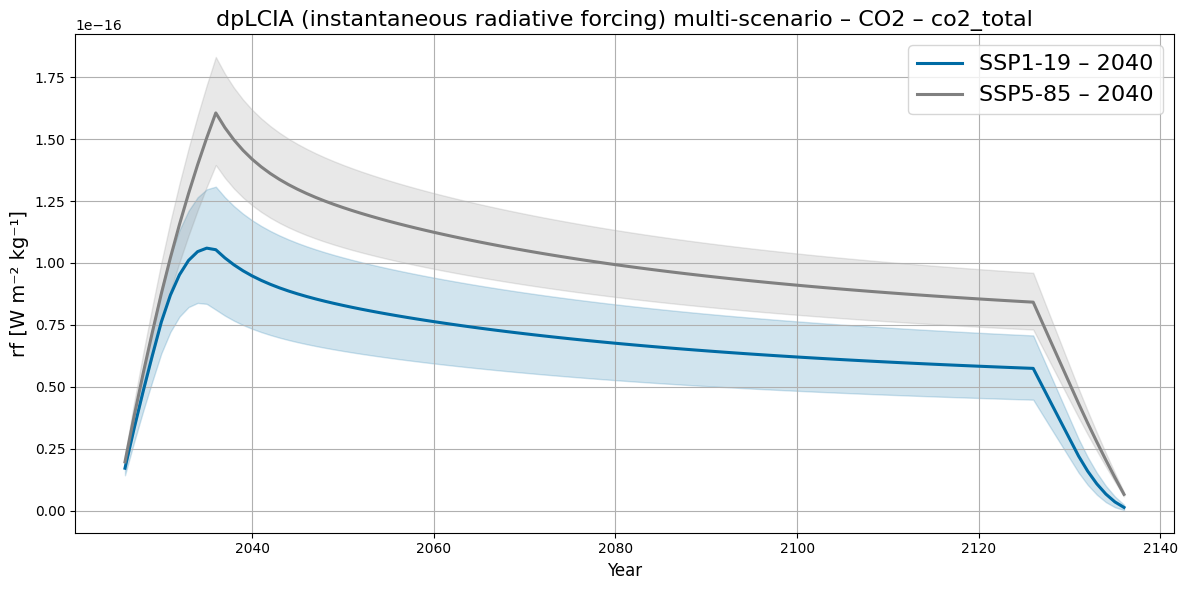

In [7]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CO2",
    subcat = "co2_total") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


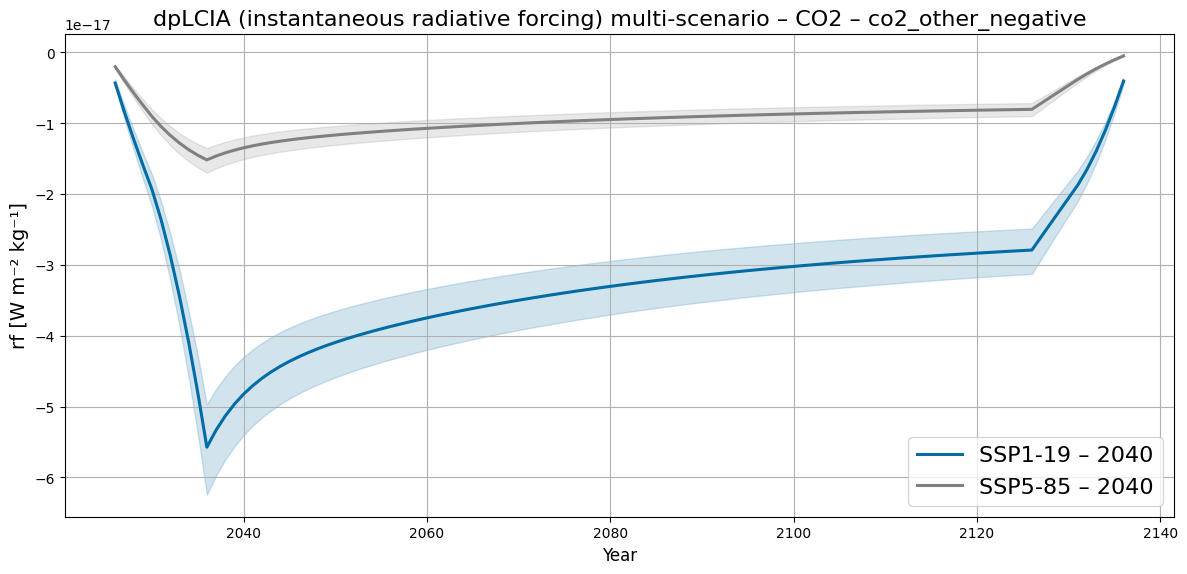

In [8]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CO2",
    subcat = "co2_other_negative") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


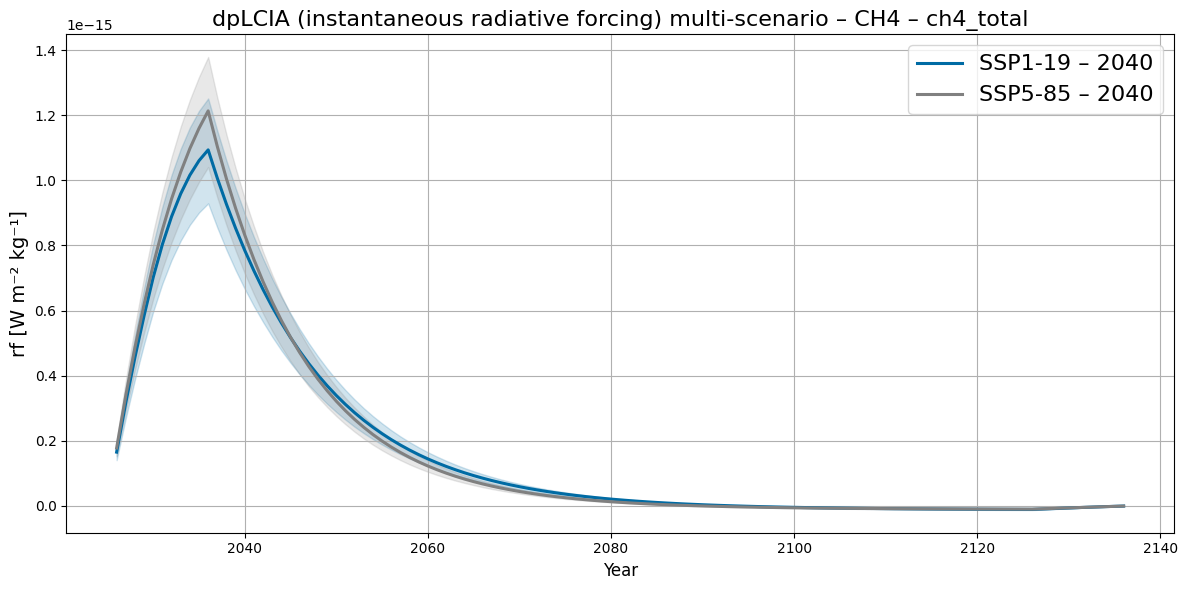

In [9]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CH4",
    subcat = "ch4_total") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


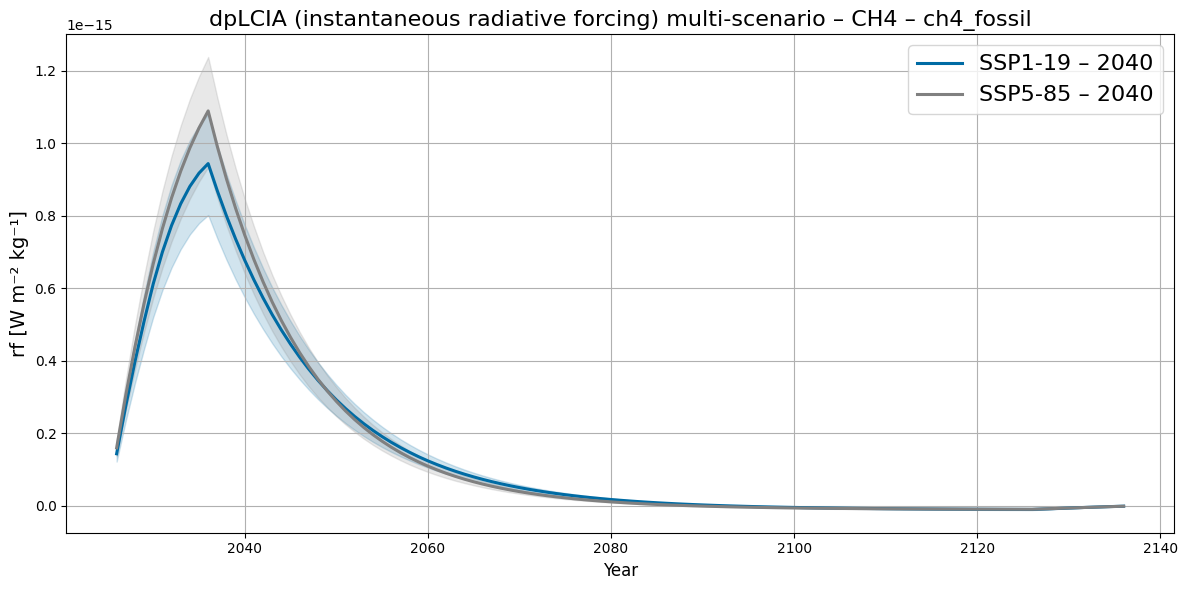

In [14]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CH4",
    subcat = "ch4_fossil") 

Gas options:  'CO2', 'CH4', 'N2O', 'ALL'
metric options: 'rf', 'agwp'
Subcategory options only for a single GHG (not for ALL): 'co2_total', 'ch4_total', 'n2o_total', 
 co2_other_negative, co2_biogenic, co2_fossil_positive, ch4_fossil, ch4_non_fossil, ch4_biomass


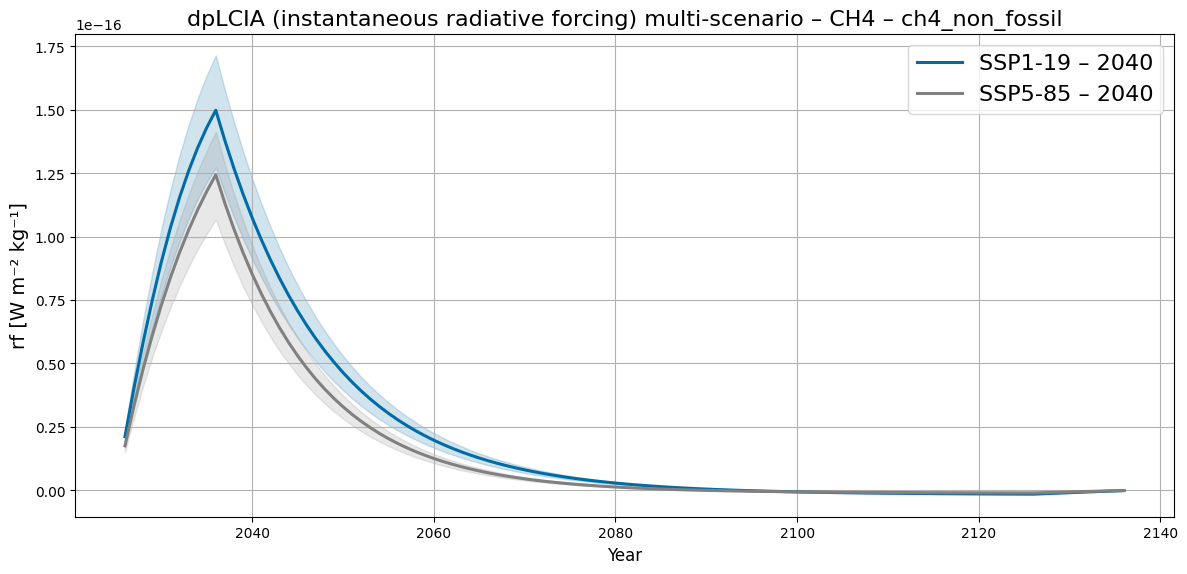

In [13]:
plot_multi_scenario_bands(
    results = results,
    metric = metric, 
    gas_to_plot = "CH4",
    subcat = "ch4_non_fossil") 

## some test

In [5]:
elec = pd.read_excel(elec_path, dtype={"flow": str})
# Restore integer
elec["flow"] = elec["flow"].astype("int64") 


pivot = elec.pivot_table(
    index='year',
    columns='flow',
    values='amount',
    aggfunc='sum'
).fillna(0)
pivot


flow,250401797516173346,250401797683945508,250401797755248709,250401797780414511,250401797805580308,250401797826551837,250401797876883529,250401797923020800,250401798040461343,250401798229205044,...,250401798837379074,250401798954819704,250401798954819709,250401799084843096,250401799110008870,250401799114203150,250401799424581653,250401799424581706,250401799567187993,250401799630102567
year,,,,,,,,,,,,,,,,,,,,,
2026,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2027,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2028,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2029,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2030,0.000033,5.093068e-07,-1.147156e-09,2.748299e-09,3.095233e-09,0.000001,0.007021,0.001154,0.000108,5.966595e-08,...,0.000001,3.199788e-10,0.000022,0.000451,0.002292,0.001087,0.000003,0.000002,0.000774,0.000616
2031,0.000031,5.115998e-07,-1.888847e-09,6.020572e-09,3.354885e-09,0.000002,0.006571,0.001455,0.000139,6.065183e-08,...,0.000001,3.264620e-10,0.000021,0.000430,0.002212,0.001265,0.000003,0.000002,0.000755,0.000584
2032,0.000029,5.138928e-07,-2.630539e-09,9.292846e-09,3.614537e-09,0.000002,0.006120,0.001756,0.000171,6.163771e-08,...,0.000002,3.329451e-10,0.000020,0.000409,0.002132,0.001444,0.000003,0.000002,0.000736,0.000551
2033,0.000027,5.161858e-07,-3.372230e-09,1.256512e-08,3.874189e-09,0.000002,0.005670,0.002057,0.000202,6.262359e-08,...,0.000002,3.394283e-10,0.000019,0.000388,0.002052,0.001622,0.000004,0.000002,0.000716,0.000519
2034,0.000025,5.184788e-07,-4.113921e-09,1.583739e-08,4.133842e-09,0.000002,0.005219,0.002358,0.000233,6.360947e-08,...,0.000002,3.459114e-10,0.000019,0.000367,0.001972,0.001800,0.000004,0.000002,0.000697,0.000487


In [6]:
# infer scenario + year from elec filename
scenario, year = parse_scenario_year_from_elec(elec_path)
print("Scenario:", scenario, "Year:", year)

# Find matching CO2 / CH4 / N2O Excel files in your ghg_dir
ghg_files = find_ghg_files(ghg_dir=ghg_dir, scenario=scenario, year=year)
ghg_files   # dict: {"CO2": "...", "CH4": "...", "N2O": "..."}

Scenario: ssp119 Year: 2040


{'CO2': '../../dpLCIA/FaIR_dpCFs/output/metrics/agwp_dcf_gwp100_tstep1CO2_ssp119_fair_start2000MY2040.xlsx',
 'CH4': '../../dpLCIA/FaIR_dpCFs/output/metrics/agwp_dcf_gwp100_tstep1CH4_ssp119_fair_start2000MY2040.xlsx',
 'N2O': '../../dpLCIA/FaIR_dpCFs/output/metrics/agwp_dcf_gwp100_tstep1N2O_ssp119_fair_start2000MY2040.xlsx'}

In [7]:
# load kernels (central + ensemble) for chosen metric (rf/agwp/gwp)
irfs = load_ghg_kernels(ghg_files, metric=metric)
# sanity check: shapes
{gas: (d["central"].shape, d["ensemble"].shape) for gas, d in irfs.items()}

{'CO2': ((101,), (101, 1001)),
 'CH4': ((101,), (101, 1001)),
 'N2O': ((101,), (101, 1001))}

### BW2 mapping

In [8]:
flow_ids = pivot.columns.astype(int).tolist()
len(flow_ids)

25

In [9]:
flow_ids = pivot.columns.astype(int).tolist()
flow_info = build_flow_info_mapping(flow_ids)

In [10]:
# Inspect mapping
for fid, fi in flow_info.items():
    print(fid, "->", fi.name, "| gas:", fi.gas, "| subtype:", fi.subtype, "| sign:", fi.sign)

250401797516173346 -> Dinitrogen monoxide | gas: N2O | subtype: n2o_all | sign: 1
250401797683945508 -> Methane, fossil | gas: CH4 | subtype: ch4_fossil | sign: 1
250401797755248709 -> Carbon dioxide, to soil or biomass stock | gas: CO2 | subtype: co2_biogenic | sign: -1
250401797780414511 -> Carbon dioxide, fossil | gas: CO2 | subtype: co2_fossil_positive | sign: 1
250401797805580308 -> Methane, from soil or biomass stock | gas: CH4 | subtype: ch4_biomass | sign: 1
250401797826551837 -> Dinitrogen monoxide | gas: N2O | subtype: n2o_all | sign: 1
250401797876883529 -> Carbon dioxide, fossil | gas: CO2 | subtype: co2_fossil_positive | sign: 1
250401797923020800 -> Carbon dioxide, in air | gas: CO2 | subtype: co2_other_negative | sign: -1
250401798040461343 -> Carbon dioxide, non-fossil | gas: CO2 | subtype: co2_biogenic | sign: 1
250401798229205044 -> Carbon dioxide, from soil or biomass stock | gas: CO2 | subtype: co2_biogenic | sign: 1
250401798443114499 -> Carbon dioxide, to soil or 

### now start dpLCIA

In [11]:
first_year =  pivot.index[0]
last_year = pivot.index[-1] 

eval_years = pd.date_range(
    f"{first_year}-01-01",
    f"{last_year + 100}-01-01",
    freq="YS",
)
n_eval = len(eval_years)

eval_years[:5], eval_years[-5:], n_eval


(DatetimeIndex(['2026-01-01', '2027-01-01', '2028-01-01', '2029-01-01',
                '2030-01-01'],
               dtype='datetime64[ns]', freq='YS-JAN'),
 DatetimeIndex(['2132-01-01', '2133-01-01', '2134-01-01', '2135-01-01',
                '2136-01-01'],
               dtype='datetime64[ns]', freq='YS-JAN'),
 111)

### 5: compute dynamic LCIA per subtype (central + 5–95 % band)

In [12]:
# Subtypes present with GHG kernels
subtypes = sorted(
    {
        fi.subtype
        for fi in flow_info.values()
        if fi.gas in irfs and fi.subtype is not None
    }
)
subtypes


['ch4_biomass',
 'ch4_fossil',
 'co2_biogenic',
 'co2_fossil_positive',
 'co2_other_negative',
 'n2o_all']

### run ONE scn/MY dplcia and plot 

In [42]:
ears, central, band, flow_info = compute_dynamic_lcia_by_category(
    elec_path=elec_path,
    ghg_dir=ghg_dir,
    metric=metric,  # rf, agwp, gwp
)



print("=== DONE: dynamic LCIA computed ===")
print("central columns:", central.columns.tolist())
print("band columns (lower):", band["lower"].columns.tolist())
print("band columns (upper):", band["upper"].columns.tolist())


=== DONE: dynamic LCIA computed ===
central columns: ['ch4_biomass', 'ch4_fossil', 'co2_biogenic', 'co2_fossil_positive', 'co2_other_negative', 'n2o_all', 'co2_total', 'ch4_total', 'n2o_total', 'all_ghg']
band columns (lower): ['ch4_biomass', 'ch4_fossil', 'co2_biogenic', 'co2_fossil_positive', 'co2_other_negative', 'n2o_all', 'co2_total', 'ch4_total', 'n2o_total', 'all_ghg']
band columns (upper): ['ch4_biomass', 'ch4_fossil', 'co2_biogenic', 'co2_fossil_positive', 'co2_other_negative', 'n2o_all', 'co2_total', 'ch4_total', 'n2o_total', 'all_ghg']


In [43]:
central["co2_other_negative"]

2026-01-01   -4.337366e-18
2027-01-01   -8.390744e-18
2028-01-01   -1.221255e-17
2029-01-01   -1.584448e-17
2030-01-01   -1.931975e-17
                  ...     
2132-01-01   -1.655829e-17
2133-01-01   -1.399004e-17
2134-01-01   -1.104935e-17
2135-01-01   -7.736947e-18
2136-01-01   -4.053589e-18
Freq: YS-JAN, Name: co2_other_negative, Length: 111, dtype: float64

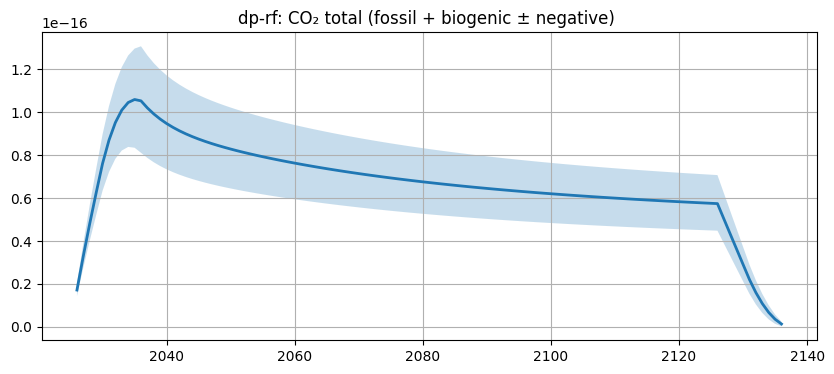

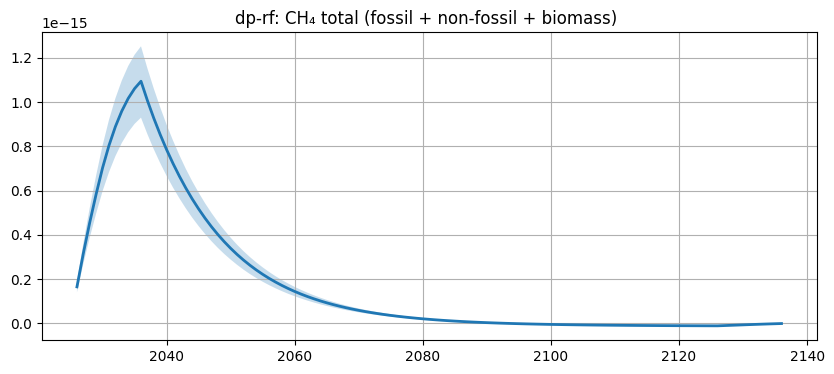

In [47]:

# -----------------------------------------------------------
# PLOTTING HELPERS
# -----------------------------------------------------------
def quick_plot(series, lower, upper, title):
    plt.figure(figsize=(10,4))
    plt.fill_between(eval_years, lower, upper, alpha=0.25)
    plt.plot(eval_years, series, lw=2)
    plt.title(title)
    plt.grid(True)
    plt.show()


# 1. CO₂ category 2.c (negative)
if "co2_other_negative" in central.columns:
    quick_plot(
        central["co2_other_negative"],
        band["lower"]["co2_other_negative"],
        band["upper"]["co2_other_negative"],
        "CO₂ (negative technology)"
    )
else:
    print("No 'co2_other_negative' found.")



# 2. CO₂ total
quick_plot(
    central["co2_total"],
    band["lower"]["co2_total"],
    band["upper"]["co2_total"],
    f"dp-{metric}: CO₂ total (fossil + biogenic ± negative) "
)

# -----------------------------------------------------------
# 3. CH₄ total
# -----------------------------------------------------------
quick_plot(
    central["ch4_total"],
    band["lower"]["ch4_total"],
    band["upper"]["ch4_total"],
    f"dp-{metric}: CH₄ total (fossil + non-fossil + biomass) "

)